# Customer Churn Prediction (Bank Customers)

**Objective:** identify which bank customers are likely to leave, using personal and account-level details.

**Dataset:** Churn Modelling Dataset, 10,000 bank customers from France, Spain, and Germany, with 14 columns covering credit score, age, balance, number of products, activity status, and whether they exited (churned). The target column is `Exited` (1 = left the bank, 0 = stayed).

This notebook covers data preparation, encoding categorical features, exploratory analysis of the most relevant variables, training two classification models (Logistic Regression and Random Forest), and analyzing feature importance to understand what actually drives churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

## Loading the data

In [2]:
df = pd.read_csv('churn_data.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(10000, 14)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## Missing values

No missing values in this dataset, so no imputation is needed. The three columns that carry no predictive information (`RowNumber`, `CustomerId`, `Surname`) are dropped before modeling.

In [4]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.shape

(10000, 11)

## Encoding categorical features

Two categorical columns need encoding before the models can use them.

`Gender` only has two values (Male/Female), so label encoding is fine here, it produces a single binary column without implying any ordering that matters.

`Geography` has three values (France, Spain, Germany), so it gets one-hot encoded instead. Label encoding would assign arbitrary numeric ordering (France=0, Germany=1, Spain=2) which would suggest Germany is somehow "between" France and Spain, which makes no sense geographically or analytically. One-hot encoding avoids that by creating separate binary columns for each country. `drop_first=True` removes one of the three dummy columns to avoid perfect multicollinearity.

In [6]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print(df.columns.tolist())
df.head()

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Exploratory data analysis

Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


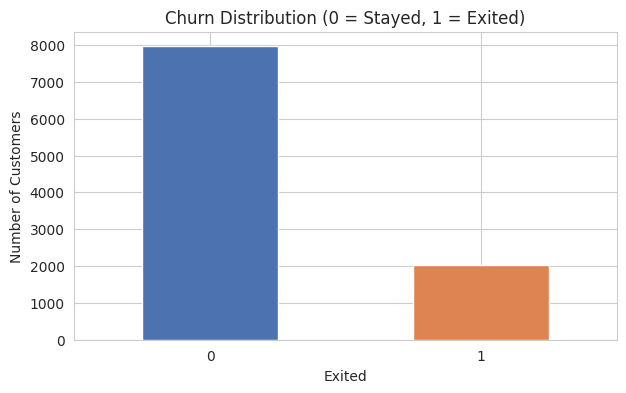

In [7]:
# overall churn rate
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100
print(churn_pct.round(1))

churn_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Churn Distribution (0 = Stayed, 1 = Exited)')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

About 20% of customers churned. The dataset is imbalanced, which will matter when interpreting the confusion matrix later.

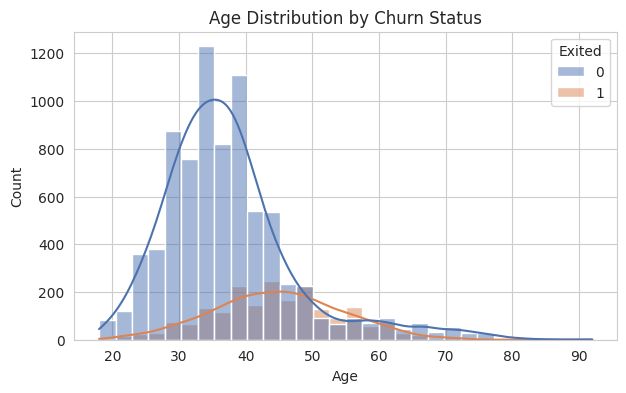

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette=['#4C72B0', '#DD8452'])
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.show()

Churned customers are noticeably older on average, the bulk of exits cluster in the 40 to 60 range, while customers who stayed skew younger.

/tmp/ipykernel_557/66432181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, palette=['#4C72B0', '#DD8452'])


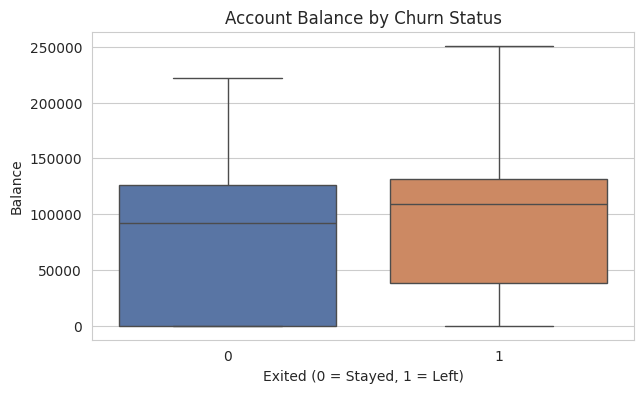

In [9]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Exited', y='Balance', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Account Balance by Churn Status')
plt.xlabel('Exited (0 = Stayed, 1 = Left)')
plt.ylabel('Balance')
plt.show()

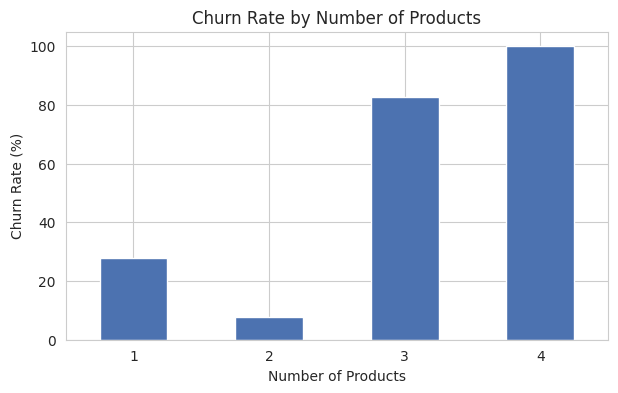

In [10]:
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', color='#4C72B0')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

Customers holding 3 or 4 products have a dramatically higher churn rate than those with 1 or 2. This is likely a sign of over-selling, customers who were pushed into products they didn't need ended up leaving.

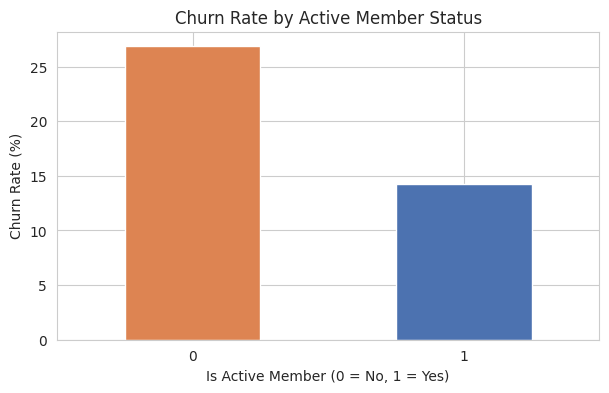

In [11]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.plot(kind='bar', color=['#DD8452', '#4C72B0'])
plt.title('Churn Rate by Active Member Status')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

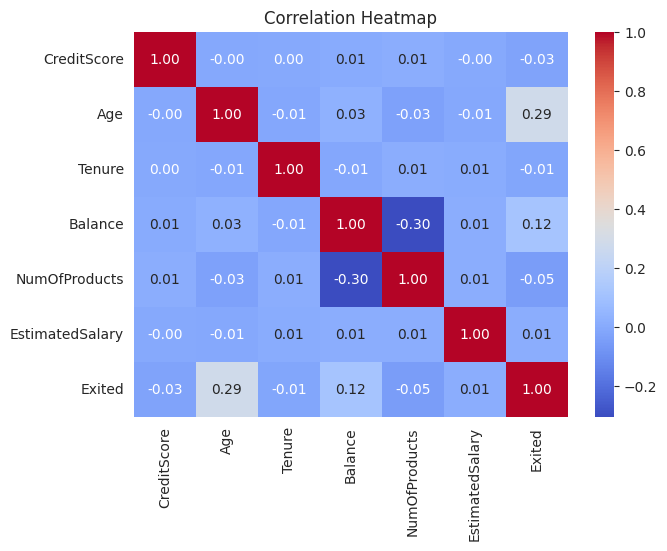

In [12]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols + ['Exited']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Preparing the data for modeling

The data is already cleaned and encoded. Split 80/20, stratified to preserve the 20/80 churn ratio in both train and test sets. Numeric features are scaled before fitting logistic regression.

In [13]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print('Churn rate in train set:', y_train.mean().round(3))
print('Churn rate in test set:', y_test.mean().round(3))

(8000, 11) (2000, 11)
Churn rate in train set: 0.204
Churn rate in test set: 0.204


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, pred_lr)
print(f'Accuracy: {acc_lr:.3f}')
print(confusion_matrix(y_test, pred_lr))

Accuracy: 0.808
[[1540   53]
 [ 331   76]]


## Random Forest

Random Forest is an ensemble of decision trees, each trained on a random subset of the data and features. It often handles imbalanced and non-linear datasets better than logistic regression, and it gives feature importances directly, which is useful for understanding what drives churn. No scaling needed here since tree-based models don't depend on feature scale.

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print(f'Accuracy: {acc_rf:.3f}')
print(confusion_matrix(y_test, pred_rf))

Accuracy: 0.861
[[1538   55]
 [ 223  184]]


## Model comparison

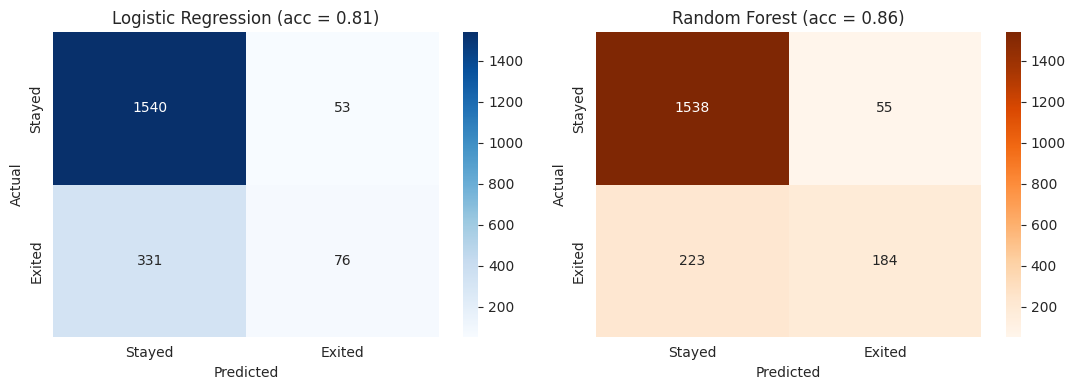

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Exited'], yticklabels=['Stayed', 'Exited'], ax=axes[0])
axes[0].set_title(f'Logistic Regression (acc = {acc_lr:.2f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stayed', 'Exited'], yticklabels=['Stayed', 'Exited'], ax=axes[1])
axes[1].set_title(f'Random Forest (acc = {acc_rf:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [18]:
print('Logistic Regression\n')
print(classification_report(y_test, pred_lr, target_names=['Stayed', 'Exited']))
print('Random Forest\n')
print(classification_report(y_test, pred_rf, target_names=['Stayed', 'Exited']))

Logistic Regression

              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
      Exited       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Random Forest

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
      Exited       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



## Feature importance

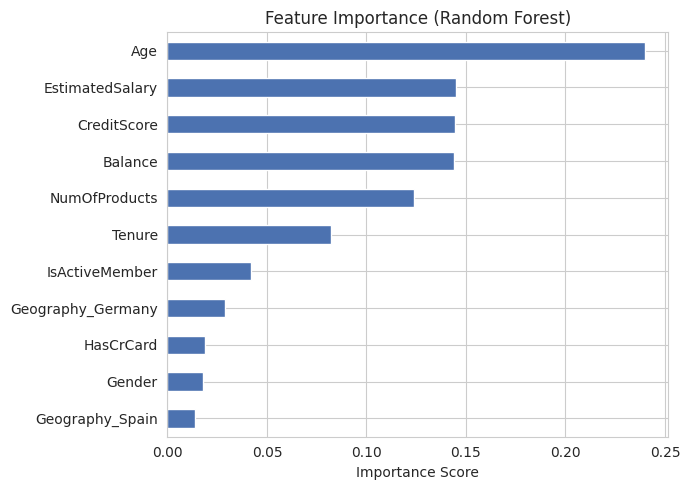

Age                  0.239730
EstimatedSalary      0.144951
CreditScore          0.144612
Balance              0.143798
NumOfProducts        0.123917
Tenure               0.081985
IsActiveMember       0.041726
Geography_Germany    0.028757
HasCrCard            0.018697
Gender               0.018053
Geography_Spain      0.013774
dtype: float64

In [19]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

feat_imp.plot(kind='barh', color='#4C72B0', figsize=(7, 5))
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

feat_imp.sort_values(ascending=False)

## Conclusion

Random Forest outperformed logistic regression, landing at around 86% accuracy versus 81%. The gap is more visible in the confusion matrix: logistic regression missed many churners (low recall on the Exited class), while Random Forest caught more of them, though both models still struggle with the minority class due to the 80/20 class imbalance.

From the feature importance chart, age is by far the strongest predictor of churn. Estimated salary, credit score, and account balance all contribute roughly equally in the middle tier. Active membership status, geography (particularly Germany), and number of products matter too but at a lower level.

The EDA surfaced a few business-relevant findings worth highlighting. Customers between 40 and 60 churn at a much higher rate than younger customers, which suggests the bank is retaining younger customers well but losing older ones, possibly to competitors offering better returns or services targeted at that demographic. Customers with 3 or 4 products exit at a sharply higher rate than those with 1 or 2, pointing to over-selling as a retention risk rather than cross-selling as a loyalty driver. Inactive members (IsActiveMember = 0) churn at roughly twice the rate of active ones, which makes inactive status an early warning signal worth acting on through engagement campaigns before a customer actually decides to leave.